In [1]:
import tensorflow as tf

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Based on the tutorial from Dr. Robert Kubler
#https://towardsdatascience.com/introduction-to-embedding-based-recommender-systems-956faceb1919/

#TODO:
#1. Define model data types that are compatible with java/swift
#2. Test the inference performance of the model
#3. Define the expanded vocabulary in the embeddings layer to account
#   to future features expansion
#4. Properly analyze accuracy (find complementary metrics to evaluate the sigmoid activation function)
#5. Test with other loss functions
#6. Add bias factors to model and introduce biased cases in database to evaluate accuracy
#7. Learn how to properly explore and measure the embeddings efficacy
#8. Explore how to solve the cold-start problem, i.e. when the model sees new data that it was not trained to handle


In [3]:
#for reproducibility
SEED = 42
#data = tfds.load('movielens/1m-ratings')
#TODO
#Add more features for the input layer of the user state definition (is-weekend, app-logins-count, location)

In [4]:
!git clone https://github.com/GilsonFrias/Banking-Dataset.git

fatal: destination path 'Banking-Dataset' already exists and is not an empty directory.


In [5]:
!ls Banking-Dataset/

banking_dataset.csv		 banking_dataset.py
Banking_Dataset_Generator.ipynb  Embeddings_Rec.ipynb


In [6]:
df = pd.read_csv('Banking-Dataset/banking_dataset.csv')

In [7]:
#df = tfds.as_dataframe(data['train'])

In [8]:
df.head(8)

,date,dom,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status,next-action,current-state-features,next-state-features
0,2024-01-01 06:07:51.743805,1,Dashboard,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,POSITIVE,Account_Details,1:Dashboard:POSITIVE,1:Account_Details:FLAT
1,2024-01-01 06:58:51.743805,1,Account_Details,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Transaction_Historical,1:Account_Details:FLAT,1:Transaction_Historical:FLAT
2,2024-01-01 06:59:51.743805,1,Transaction_Historical,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard,1:Transaction_Historical:FLAT,1:Dashboard:FLAT
3,2024-01-01 13:52:10.298082,1,Dashboard,2e52d071-3128-44a2-847a-0a10ee5cc3bd,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard,1:Dashboard:FLAT,1:Dashboard:FLAT
4,2024-01-01 18:07:49.691923,1,Dashboard,b2ee3a5c-e4e8-4ce0-8af8-6eaf5b6be3f9,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Account_Details,1:Dashboard:FLAT,1:Account_Details:FLAT
5,2024-01-01 18:40:49.691923,1,Account_Details,b2ee3a5c-e4e8-4ce0-8af8-6eaf5b6be3f9,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Transaction_Historical,1:Account_Details:FLAT,1:Transaction_Historical:FLAT
6,2024-01-01 18:58:49.691923,1,Transaction_Historical,b2ee3a5c-e4e8-4ce0-8af8-6eaf5b6be3f9,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard,1:Transaction_Historical:FLAT,1:Dashboard:FLAT
7,2024-01-01 19:07:22.127316,1,Dashboard,a35fd0b6-644e-4af6-84cf-50a88da3cc6f,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Account_Details,1:Dashboard:FLAT,1:Account_Details:FLAT


In [9]:
#Get the total set of user actions
non_payment_actions = ['Account_Details', 'Dashboard', 'Transaction_Historical']
payment_actions = np.delete(df['user-action'].unique(), np.isin(df['user-action'].unique(), non_payment_actions))
print(payment_actions)

['BENEF_INTERBANK_PAYMENT:RENT' 'BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO'
 'SERVICE_PAYMENT:ELECTRICITY' 'SERVICE_PAYMENT:INTERNET'
 'SERVICE_PAYMENT:PHONE' 'SERVICE_PAYMENT:NETFLIX' 'SERVICE_PAYMENT:WATER'
 'PAYMENT_EXPRESS:PURCHASES']


In [10]:
#Create a column login-state to label those actions that are within the non_payment_actions list and that correspond to mostly login activities
login_state_actions = df['user-action'].isin(non_payment_actions).astype(int)
df.insert(2, 'login-state', login_state_actions)
df.head(5)

,date,dom,login-state,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status,next-action,current-state-features,next-state-features
0,2024-01-01 06:07:51.743805,1,1,Dashboard,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,POSITIVE,Account_Details,1:Dashboard:POSITIVE,1:Account_Details:FLAT
1,2024-01-01 06:58:51.743805,1,1,Account_Details,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Transaction_Historical,1:Account_Details:FLAT,1:Transaction_Historical:FLAT
2,2024-01-01 06:59:51.743805,1,1,Transaction_Historical,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard,1:Transaction_Historical:FLAT,1:Dashboard:FLAT
3,2024-01-01 13:52:10.298082,1,1,Dashboard,2e52d071-3128-44a2-847a-0a10ee5cc3bd,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard,1:Dashboard:FLAT,1:Dashboard:FLAT
4,2024-01-01 18:07:49.691923,1,1,Dashboard,b2ee3a5c-e4e8-4ce0-8af8-6eaf5b6be3f9,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Account_Details,1:Dashboard:FLAT,1:Account_Details:FLAT


In [11]:
df[df['login-state']==0]

,date,dom,login-state,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status,next-action,current-state-features,next-state-features
71,2024-01-14 00:29:11.050800,14,0,BENEF_INTERBANK_PAYMENT:RENT,550843ba-2a78-4d90-884f-8fd49f09a6f7,2379225.0,dqUy7gI2Q0axcw65lBEyUg==,953692.0,NEGATIVE,Dashboard,14:BENEF_INTERBANK_PAYMENT:RENT:NEGATIVE,14:Dashboard:FLAT
74,2024-01-14 00:59:11.932177,14,0,BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO,3b6d3e89-ed24-4049-a731-52faf4d0d4d2,2371248.0,dqUy7gI2Q0axcw65lBEyUg==,945715.0,FLAT,Dashboard,14:BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO:FLAT,14:Dashboard:FLAT
77,2024-01-14 01:37:04.333496,14,0,SERVICE_PAYMENT:ELECTRICITY,889fb14f-1ba9-492d-9de8-39f560567f90,2369164.0,dqUy7gI2Q0axcw65lBEyUg==,943631.0,NEGATIVE,SERVICE_PAYMENT:INTERNET,14:SERVICE_PAYMENT:ELECTRICITY:NEGATIVE,14:SERVICE_PAYMENT:INTERNET:NEGATIVE
78,2024-01-14 01:48:04.333496,14,0,SERVICE_PAYMENT:INTERNET,889fb14f-1ba9-492d-9de8-39f560567f90,2366764.0,dqUy7gI2Q0axcw65lBEyUg==,941231.0,NEGATIVE,SERVICE_PAYMENT:PHONE,14:SERVICE_PAYMENT:INTERNET:NEGATIVE,14:SERVICE_PAYMENT:PHONE:NEGATIVE
79,2024-01-14 01:53:04.333496,14,0,SERVICE_PAYMENT:PHONE,889fb14f-1ba9-492d-9de8-39f560567f90,2365263.0,dqUy7gI2Q0axcw65lBEyUg==,939730.0,NEGATIVE,Dashboard,14:SERVICE_PAYMENT:PHONE:NEGATIVE,14:Dashboard:FLAT
...,...,...,...,...,...,...,...,...,...,...,...,...
9501,2025-12-13 13:58:03.518611,13,0,SERVICE_PAYMENT:NETFLIX,142b4f15-08df-4a2c-b834-0f7096cbb21a,2461402.0,dqUy7gI2Q0axcw65lBEyUg==,1035869.0,NEGATIVE,BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO,13:SERVICE_PAYMENT:NETFLIX:NEGATIVE,13:BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO:NEGA...
9502,2025-12-13 13:59:03.518611,13,0,BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO,142b4f15-08df-4a2c-b834-0f7096cbb21a,2456077.0,dqUy7gI2Q0axcw65lBEyUg==,1030544.0,NEGATIVE,PAYMENT_EXPRESS:PURCHASES,13:BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO:NEGA...,13:PAYMENT_EXPRESS:PURCHASES:FLAT
9503,2025-12-13 13:58:03.518611,13,0,PAYMENT_EXPRESS:PURCHASES,142b4f15-08df-4a2c-b834-0f7096cbb21a,2456077.0,dqUy7gI2Q0axcw65lBEyUg==,1030544.0,FLAT,SERVICE_PAYMENT:PHONE,13:PAYMENT_EXPRESS:PURCHASES:FLAT,13:SERVICE_PAYMENT:PHONE:NEGATIVE
9504,2025-12-13 13:59:03.518611,13,0,SERVICE_PAYMENT:PHONE,142b4f15-08df-4a2c-b834-0f7096cbb21a,2454590.0,dqUy7gI2Q0axcw65lBEyUg==,1029057.0,NEGATIVE,SERVICE_PAYMENT:INTERNET,13:SERVICE_PAYMENT:PHONE:NEGATIVE,13:SERVICE_PAYMENT:INTERNET:NEGATIVE


In [12]:
#Create target column y to signal a proper prediction in next-action
#Initially all predictions are positive, we will augment the data to include erroneous scenarios
df.insert(df.shape[1], 'prediction-label', np.ones(df.shape[0], dtype=bool))

In [13]:
#Update current-state-features to include in the compressed feature representation the total and main SAVINGS balances
#df['current-state-features'] = pd.Series([":".join([str(row['current-state-features']), str(row['total-balance']), str(row['main-savings-balance'])]) for index, row in df.iterrows()], name='concat-features')

In [14]:
#Identify sessions were at least a payment was made
sessions_with_payments = df['session-Id'][df['next-action'].isin(payment_actions)].unique()
sessions_with_payments.shape

(69,)

In [15]:
#next_consecuential_actions = np.full(df.shape[0], "",  dtype=str)
#payment_in_session = np.zeros(df.shape[0], dtype=int)

In [16]:
df[df['session-Id']==sessions_with_payments[10]]

,date,dom,login-state,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status,next-action,current-state-features,next-state-features,prediction-label
1260,2024-04-13 01:04:13.509244,13,1,Dashboard,098e7c04-123f-47d4-aa27-0a67d3198944,2402786.0,dqUy7gI2Q0axcw65lBEyUg==,977253.0,POSITIVE,Account_Details,13:Dashboard:POSITIVE,13:Account_Details:NEGATIVE,True
1261,2024-04-13 01:59:13.509244,13,1,Account_Details,098e7c04-123f-47d4-aa27-0a67d3198944,2396954.0,dqUy7gI2Q0axcw65lBEyUg==,971421.0,NEGATIVE,PAYMENT_EXPRESS:PURCHASES,13:Account_Details:NEGATIVE,13:PAYMENT_EXPRESS:PURCHASES:NEGATIVE,True
1262,2024-04-13 01:59:13.509244,13,0,PAYMENT_EXPRESS:PURCHASES,098e7c04-123f-47d4-aa27-0a67d3198944,2386954.0,dqUy7gI2Q0axcw65lBEyUg==,961421.0,NEGATIVE,BENEF_INTERBANK_PAYMENT:RENT,13:PAYMENT_EXPRESS:PURCHASES:NEGATIVE,13:BENEF_INTERBANK_PAYMENT:RENT:NEGATIVE,True
1263,2024-04-13 01:59:13.509244,13,0,BENEF_INTERBANK_PAYMENT:RENT,098e7c04-123f-47d4-aa27-0a67d3198944,2378899.0,dqUy7gI2Q0axcw65lBEyUg==,953366.0,NEGATIVE,BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO,13:BENEF_INTERBANK_PAYMENT:RENT:NEGATIVE,13:BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO:FLAT,True
1264,2024-04-13 01:59:13.509244,13,0,BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO,098e7c04-123f-47d4-aa27-0a67d3198944,2378899.0,dqUy7gI2Q0axcw65lBEyUg==,953366.0,FLAT,Dashboard,13:BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO:FLAT,14:Dashboard:FLAT,True


In [17]:
##u#Add dow column to df
#date_format = "%Y-%m-%d %H:%M:%S"

#dow = [datetime.strptime(date, date_format).day for date in df['date']]
#df.insert(1, "dow", dow)

In [18]:
#Add next-action column with the one sample shifted user-action column
#shifted_actions = df['user-action'][1:]
#df.insert(df.shape[1], 'next-action', pd.concat([shifted_actions, pd.Series(['Dashboard'])], ignore_index=True))
#df

In [19]:
#Exploratory Data Analisis

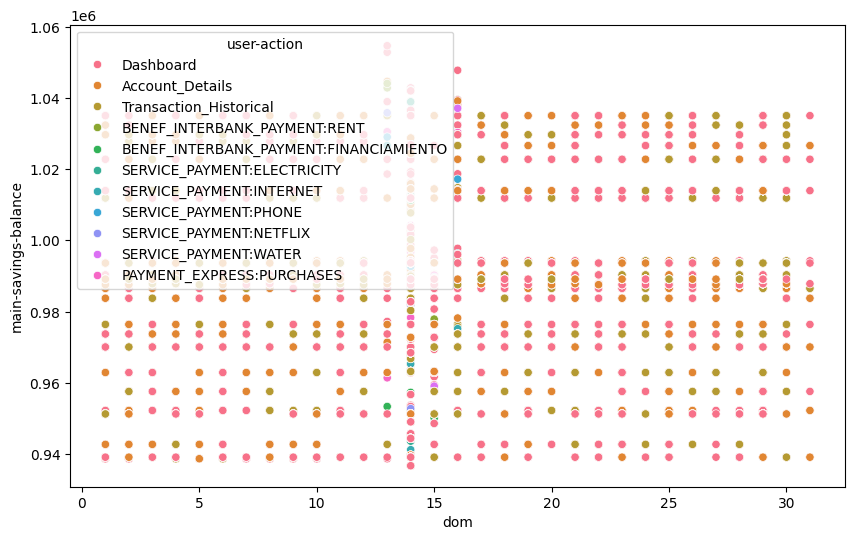

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='dom', y='main-savings-balance', hue='user-action', ax=ax)
plt.show()

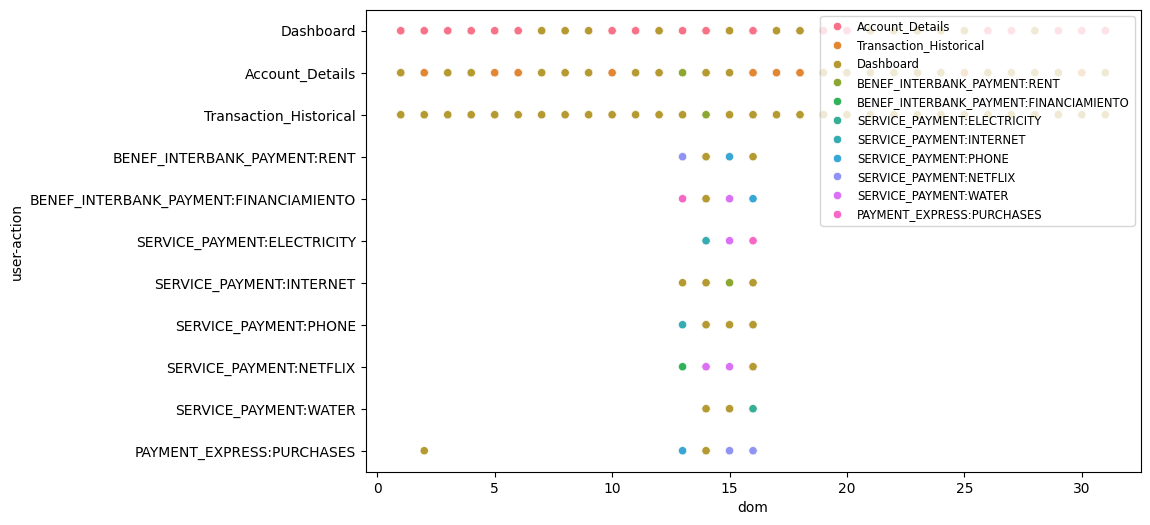

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='dom', y='user-action', hue='next-action', ax=ax)
plt.legend(loc="upper right", fontsize='small', title_fontsize='medium')
plt.show()

In [22]:
#Build output labels from the sessions with payments performed
#payment_sessions = df[df['user-action'].isin(payment_actions)]['session-Id'].unique()
#y = df['session-Id'].isin(payment_sessions)
#df[y].head(8)
#y = df['next-action']

In [23]:
#Drop non necesary columns
#df.drop(['date', 'session-Id', 'account-from'], axis=1, inplace=True)
#df.head(8)
#df.astype({'total-balance': 'float64', 'main-savings-balance': 'float64'}).head(8)

In [24]:
#Create a single categorical feature with the main features
#df['current-state-features'] = pd.Series([":".join([str(row['dow']), row['user-action'], row['main-savings-status']]) for index, row in df.iterrows()], name='concat-features')

In [25]:
#df.head()

In [26]:
#Add next-action column with the shifted
#shifted_actions = df['current-state-features'][1:]
#df.insert(df.shape[1], 'next-state-features', pd.concat([shifted_actions, pd.Series(['Dashboard'])], ignore_index=True))
#df

In [27]:
df.head()

,date,dom,login-state,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status,next-action,current-state-features,next-state-features,prediction-label
0,2024-01-01 06:07:51.743805,1,1,Dashboard,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,POSITIVE,Account_Details,1:Dashboard:POSITIVE,1:Account_Details:FLAT,True
1,2024-01-01 06:58:51.743805,1,1,Account_Details,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Transaction_Historical,1:Account_Details:FLAT,1:Transaction_Historical:FLAT,True
2,2024-01-01 06:59:51.743805,1,1,Transaction_Historical,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard,1:Transaction_Historical:FLAT,1:Dashboard:FLAT,True
3,2024-01-01 13:52:10.298082,1,1,Dashboard,2e52d071-3128-44a2-847a-0a10ee5cc3bd,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard,1:Dashboard:FLAT,1:Dashboard:FLAT,True
4,2024-01-01 18:07:49.691923,1,1,Dashboard,b2ee3a5c-e4e8-4ce0-8af8-6eaf5b6be3f9,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Account_Details,1:Dashboard:FLAT,1:Account_Details:FLAT,True


In [29]:
df[df['next-action'].isin(non_payment_actions)].sample(frac=0.35, random_state=SEED).shape

(3353, 13)

In [30]:
df[df['next-action'].isin(payment_actions)].sample(frac=0.35, random_state=SEED).shape

(45, 13)

In [31]:
#Augment the dataset with negative scenarios were next-action would
#point to a randomly picked action different to the actual measured next-action, this to teach the embedding
#model to not be biased on always correlating those actions with the non payment states in current-state-features (as there is a major number
#of non-payment-actions in the dataset)

In [32]:
#Locate the payment and non-payment actions samples to alter
non_payment_indx = df[df['next-action'].isin(non_payment_actions)].sample(frac=0.35, random_state=SEED).index
payment_indx = df[df['next-action'].isin(payment_actions)].sample(frac=0.35, random_state=SEED).index

#Augment data with false positives (i.e., predicted a payment when it was not the actual next-action)
df.loc[non_payment_indx, 'next-action'] = np.random.choice(payment_actions, size=non_payment_indx.shape[0])
df.loc[non_payment_indx,'prediction-label'] = False

#Augment data with false negatives (i.e., predicted a session login/dashboard when a payment was due next)
df.loc[payment_indx, 'next-action'] = np.random.choice(non_payment_actions, size=payment_indx.shape[0])
df.loc[non_payment_indx,'prediction-label'] = False

In [33]:
df.head()

,date,dom,login-state,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status,next-action,current-state-features,next-state-features,prediction-label
0,2024-01-01 06:07:51.743805,1,1,Dashboard,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,POSITIVE,SERVICE_PAYMENT:INTERNET,1:Dashboard:POSITIVE,1:Account_Details:FLAT,False
1,2024-01-01 06:58:51.743805,1,1,Account_Details,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Transaction_Historical,1:Account_Details:FLAT,1:Transaction_Historical:FLAT,True
2,2024-01-01 06:59:51.743805,1,1,Transaction_Historical,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard,1:Transaction_Historical:FLAT,1:Dashboard:FLAT,True
3,2024-01-01 13:52:10.298082,1,1,Dashboard,2e52d071-3128-44a2-847a-0a10ee5cc3bd,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,PAYMENT_EXPRESS:PURCHASES,1:Dashboard:FLAT,1:Dashboard:FLAT,False
4,2024-01-01 18:07:49.691923,1,1,Dashboard,b2ee3a5c-e4e8-4ce0-8af8-6eaf5b6be3f9,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Account_Details,1:Dashboard:FLAT,1:Account_Details:FLAT,True


In [34]:
'''
Encode a set of features for a current App State into a 16 bits representation
# params:
dom: int (5 bits), a positive number in the range [1-31] that represents the current day-of-month
login_status: int (1 bit), a boolean bit flag that signals if the current state corresponds to a new signin (1) or transactional (0) state
feature_key1: int (5 bits), an index that points to a feature key (i.e., accountNumber, accountStatus)
feature_key2: int (5 bits), an index that points to a secundary feature key
'''
def encode(dom=1, login_status=1, feature_key1=1, feature_key2=1):
    args = locals()
    #Avoid processing strings
    if [val for val in args.values() if type(val)!=int]!=[]:
        raise ValueError("[Error] only integers are allowed as input values")

    #Avoid processing negative ints and numbers with more than 16 bits representations
    if True in [True for val in args.values() if (val>2**16 or val<0)]:
        raise OverflowError("[Error] only numbers representable as unsigned 16 bits are allowed as input values")

    #Create a b'00011111' bitmask to target and accomodate the 5 bits input args
    five_bits_bitmask = np.uint16(31)
    #Convert dom to 16 bits and shift it left to the beginning of the encoded uint16
    dom_uint16 = (five_bits_bitmask & np.uint16(dom)) << 11
    #Convert login_status to 16 bits and shift it left 10 bits
    login_status_uint16 = (np.uint16(1) & np.uint16(login_status)) << 10
    encoded = login_status_uint16 | dom_uint16
    #Convert feature_keys1 to 16 bits and shift it left 5 bits
    feature_key1_uint16 = (five_bits_bitmask & np.uint16(feature_key1)) << 5
    encoded = encoded | feature_key1_uint16
    #Convert feature_keys2 to 16 bits and shift it left 0 bits
    feature_key2_uint16 = (five_bits_bitmask & np.uint16(feature_key2))
    encoded = encoded | feature_key2_uint16
    return encoded

In [35]:
encoded_value = encode(dom=15, login_status=1, feature_key1=10, feature_key2=20)
print(f"Encoded value: {encoded_value}")

# Test with different values
encoded_value_2 = encode(dom=30, login_status=0, feature_key1=5, feature_key2=25)
print(f"Encoded value 2: {encoded_value_2}")

# Test edge cases
encoded_value_3 = encode(dom=1, login_status=0, feature_key1=1, feature_key2=1)
print(f"Encoded value 3: {encoded_value_3}")

encoded_value_4 = encode(dom=31, login_status=1, feature_key1=31, feature_key2=31)
print(f"Encoded value 4: {encoded_value_4}")

Encoded value: 32084
Encoded value 2: 61625
Encoded value 3: 2081
Encoded value 4: 65535


In [36]:
'''
Decode a 16 bits representation back into its original features
# params:
encoded_value: int (16 bits), the encoded representation of the app state
'''
def decode(encoded_value):
    # Recreate the five-bit mask
    five_bits_bitmask = np.uint16(31)
    one_bit_bitmask = np.uint16(1)

    # Extract feature_key2 (last 5 bits)
    feature_key2 = (encoded_value & five_bits_bitmask).item()

    # Extract feature_key1 (next 5 bits)
    feature_key1 = ((encoded_value >> 5) & five_bits_bitmask).item()

    # Extract login_status (next 1 bit)
    login_status = ((encoded_value >> 10) & one_bit_bitmask).item()

    # Extract dom (first 5 bits)
    dom = ((encoded_value >> 11) & five_bits_bitmask).item()

    return {"dom": dom, "login_status": login_status, "feature_key1": feature_key1, "feature_key2": feature_key2}


In [37]:
# Test the decode function with the previously encoded values

decoded_value_1 = decode(encoded_value)
print(f"Decoded value 1: {decoded_value_1}")

decoded_value_2 = decode(encoded_value_2)
print(f"Decoded value 2: {decoded_value_2}")

decoded_value_3 = decode(encoded_value_3)
print(f"Decoded value 3: {decoded_value_3}")

decoded_value_4 = decode(encoded_value_4)
print(f"Decoded value 4: {decoded_value_4}")

# Verify against original inputs
original_dom = 15
original_login_status = 1
original_feature_key1 = 10
original_feature_key2 = 20

assert decoded_value_1['dom'] == original_dom, "DOM mismatch"
assert decoded_value_1['login_status'] == original_login_status, "Login Status mismatch"
assert decoded_value_1['feature_key1'] == original_feature_key1, "Feature Key 1 mismatch"
assert decoded_value_1['feature_key2'] == original_feature_key2, "Feature Key 2 mismatch"

print("Verification successful for first encoded value!")

Decoded value 1: {'dom': 15, 'login_status': 1, 'feature_key1': 10, 'feature_key2': 20}
Decoded value 2: {'dom': 30, 'login_status': 0, 'feature_key1': 5, 'feature_key2': 25}
Decoded value 3: {'dom': 1, 'login_status': 0, 'feature_key1': 1, 'feature_key2': 1}
Decoded value 4: {'dom': 31, 'login_status': 1, 'feature_key1': 31, 'feature_key2': 31}
Verification successful for first encoded value!


In [38]:
'''
Lookup tables that provide the range of int required to encode the feature space to feed as inputs to the model
'''

account_status_map = {
    "NEGATIVE": 1,
    "FLAT": 2,
    "POSITIVE": 3
}

unique_user_actions = df['user-action'].unique()
user_actions_map = dict([(unique_user_actions[indx], indx) for indx in range(unique_user_actions.size)])

unique_accounts = df['account-from'].unique()
accounts_map = dict([(unique_accounts[indx], indx) for indx in range(unique_accounts.size)])


In [39]:
#Create the encoded current-state and next-state columns
df['encoded-current-state'] = df.apply(lambda row: encode(dom=row['dom'], login_status=row['login-state'], feature_key1=accounts_map[row['account-from']], feature_key2=user_actions_map[row['user-action']]) if(row['login-state']==0) else
    encode(dom=row['dom'], login_status=row['login-state'], feature_key1=accounts_map[row['account-from']], feature_key2=account_status_map[row['main-savings-status']]), axis=1)

df['encoded-next-state'] = df.apply(lambda row: np.uint16(user_actions_map[row['next-action']]), axis=1)

In [40]:
df.head()

,date,dom,login-state,user-action,session-Id,total-balance,account-from,main-savings-balance,main-savings-status,next-action,current-state-features,next-state-features,prediction-label,encoded-current-state,encoded-next-state
0,2024-01-01 06:07:51.743805,1,1,Dashboard,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,POSITIVE,SERVICE_PAYMENT:INTERNET,1:Dashboard:POSITIVE,1:Account_Details:FLAT,False,3075,6
1,2024-01-01 06:58:51.743805,1,1,Account_Details,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Transaction_Historical,1:Account_Details:FLAT,1:Transaction_Historical:FLAT,True,3074,2
2,2024-01-01 06:59:51.743805,1,1,Transaction_Historical,27093fae-1fae-4f67-a9e2-671161310d39,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Dashboard,1:Transaction_Historical:FLAT,1:Dashboard:FLAT,True,3074,0
3,2024-01-01 13:52:10.298082,1,1,Dashboard,2e52d071-3128-44a2-847a-0a10ee5cc3bd,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,PAYMENT_EXPRESS:PURCHASES,1:Dashboard:FLAT,1:Dashboard:FLAT,False,3074,10
4,2024-01-01 18:07:49.691923,1,1,Dashboard,b2ee3a5c-e4e8-4ce0-8af8-6eaf5b6be3f9,2364225.0,dqUy7gI2Q0axcw65lBEyUg==,938692.0,FLAT,Account_Details,1:Dashboard:FLAT,1:Account_Details:FLAT,True,3074,1


In [41]:
#Augment the dataset with negative scenarios were next-action would
#point to a randomly picked action different to the actual measured next-action, this to teach the embedding
#model to not be biased on always correlating those actions with the non payment states in current-state-features (as there is a major number
#of non-payment-actions in the dataset)

'''
x = df[['current-state-features', 'next-action', 'prediction-label']]
indx = x[df['prediction-label']==False].sample(frac=0.45, random_state=SEED).index
complement_indx = x.index.difference(indx)
#Update next-action for the random pool with a random payment_action
#prediction-label stays False for those cases
x.loc[indx, 'next-action'] = np.random.choice(payment_actions, size=indx.shape[0])
#For the remanining non-payment-actions turn the prediction-label to True as we
# allow the model to count the non-payment-action prediction as correct
x.loc[complement_indx, 'prediction-label'] = True
'''

"\nx = df[['current-state-features', 'next-action', 'prediction-label']]\nindx = x[df['prediction-label']==False].sample(frac=0.45, random_state=SEED).index\ncomplement_indx = x.index.difference(indx)\n#Update next-action for the random pool with a random payment_action\n#prediction-label stays False for those cases\nx.loc[indx, 'next-action'] = np.random.choice(payment_actions, size=indx.shape[0])\n#For the remanining non-payment-actions turn the prediction-label to True as we\n# allow the model to count the non-payment-action prediction as correct\nx.loc[complement_indx, 'prediction-label'] = True\n"

In [42]:
x = df[['encoded-current-state', 'encoded-next-state', 'prediction-label']]
x.shape

(9708, 3)

In [43]:
#Split train and training sets
TRAIN_SAMPLES = 8000
x_train = x[['encoded-current-state', 'encoded-next-state']].iloc[:TRAIN_SAMPLES]
x_test = x[['encoded-current-state', 'encoded-next-state']].iloc[TRAIN_SAMPLES:]

y_train = x['prediction-label'].iloc[:TRAIN_SAMPLES]
y_test = x['prediction-label'].iloc[TRAIN_SAMPLES:]

In [44]:
#vocab = iris_df['iris_class_name'].unique()
#embedding_dimension = 10
#lookup = tf.keras.layers.StringLookup(vocabulary=vocab)
#embedding = tf.keras.layers.Embedding(input_dim=lookup.vocabulary_size(), output_dim=embedding_dimension)

In [45]:
#import tensorflow_datasets as tfds

#data = tfds.load("movielens/1m-ratings")

In [46]:
'''
#Defining model signature:
The recommendation to have more inpact should be given at
the beginning of the user session
- input(As[t]): App state As at time t
- input(Pa[t-x]): a previously registered payment action Pa registered as
                a successful payment at some previous time t-x
- output(p(Pa[t+1]|As[t])): the probability of a likely transition to state Pa
                at time t+1 given the current state As at time t
'''

'\n#Defining model signature:\nThe recommendation to have more inpact should be given at\nthe beginning of the user session\n- input(As[t]): App state As at time t\n- input(Pa[t-x]): a previously registered payment action Pa registered as\n                a successful payment at some previous time t-x\n- output(p(Pa[t+1]|As[t])): the probability of a likely transition to state Pa\n                at time t+1 given the current state As at time t\n'

In [47]:
x_train.head()

,encoded-current-state,encoded-next-state
0,3075,6
1,3074,2
2,3074,0
3,3074,10
4,3074,1


In [48]:
#building TF pipelines

vocabulary_size = 2**16

#Current App state pipeline

app_state_input = tf.keras.layers.Input(shape=(1,), name='app_state', dtype=tf.uint16)
#app_state_as_int = tf.keras.layers.StringLookup(vocabulary=all_states, name='app_state_as_int')(app_state_input)
app_state_embedding = tf.keras.layers.Embedding(vocabulary_size, output_dim=32, name='app_state_embedding')(app_state_input)

In [49]:
#Next App state pipeline

next_payment_action_input = tf.keras.layers.Input(shape=(1,), name='next_payment_action', dtype=tf.uint16)
#payment_action_as_int = tf.keras.layers.StringLookup(vocabulary=all_actions, name='payment_action_as_int')(payment_action_input)
next_payment_action_embedding = tf.keras.layers.Embedding(vocabulary_size, output_dim=32, name='payment_action_embedding')(next_payment_action_input)

In [50]:
#dot product
dot_product = tf.keras.layers.Dot(axes=2, name='dot_product')([app_state_embedding, next_payment_action_embedding])
flatten = tf.keras.layers.Flatten(name='flatten')(dot_product)

In [51]:
#Model assembly
outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='prediction')(flatten)
model = tf.keras.Model(inputs=[app_state_input, next_payment_action_input], outputs=outputs)

In [52]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [81]:
x_train.head()

array([ 3075,  3074,  5122,  9218, 11266, 13314, 15362, 17410, 19458,
       21506, 27650, 29699, 28675, 29698, 29697, 28676, 28677, 28678,
       28679, 28680, 31746, 33794, 35842, 37890, 39938, 44034, 46082,
       48130, 50178, 52226, 56322, 58370, 60418, 62466, 64514,  7170,
       23554, 25602, 31747, 30725, 30729, 30724, 30727, 31745, 30730,
       41986, 54274, 28682, 27651, 27649, 26634, 26627, 26628, 30723,
        5123, 30726, 33795, 33793, 32774, 32776, 32775, 32771, 28681,
       30728, 32777], dtype=uint16)

In [54]:
#Fit on model
model.fit(
    x = {
        'app_state': x_train['encoded-current-state'],
        'next_payment_action': x_train['encoded-next-state']
    },
    y = y_train.astype(int).values,
    batch_size=256,
    epochs=100,
    validation_split=0.1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=1, restore_best_weights=True)]
)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.8129 - loss: 0.6653 - val_accuracy: 0.9862 - val_loss: 0.5940
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9943 - loss: 0.4507 - val_accuracy: 0.9900 - val_loss: 0.3031
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9944 - loss: 0.2003 - val_accuracy: 0.9925 - val_loss: 0.1371
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9942 - loss: 0.0963 - val_accuracy: 0.9925 - val_loss: 0.0789
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9936 - loss: 0.0591 - val_accuracy: 0.9925 - val_loss: 0.0572
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9939 - loss: 0.0435 - val_accuracy: 0.9925 - val_loss: 0.0474
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9928 - loss: 0.0358 - val_accuracy: 0.9912 - val_loss: 0.0426
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9926 - loss: 0.0314 - val_accuracy: 0.

In [82]:
model.evaluate(
  x = {
        'app_state': x_test['encoded-current-state'],
        'next_payment_action': x_test['encoded-next-state']
    },
    y = y_test.astype(int).values,
)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9924 - loss: 0.0289


[0.028871722519397736, 0.9923887848854065]

In [84]:
_indx = 400
model.predict({
  'app_state': x_test['encoded-current-state'][500:512], #.astype('string'),
  'next_payment_action': x_test['encoded-next-state'][500:512], #.astype('string')
})



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


array([[9.9839306e-01],
       [9.9681759e-01],
       [9.9948651e-01],
       [9.9999958e-01],
       [5.9817830e-04],
       [9.9998444e-01],
       [1.4504185e-03],
       [9.9999958e-01],
       [9.9999595e-01],
       [9.9999958e-01],
       [1.0852173e-03],
       [5.9817825e-04]], dtype=float32)

In [85]:
y_test[500:512]

,prediction-label
8500,True
8501,True
8502,True
8503,True
8504,False
8505,True
8506,False
8507,True
8508,True
8509,True


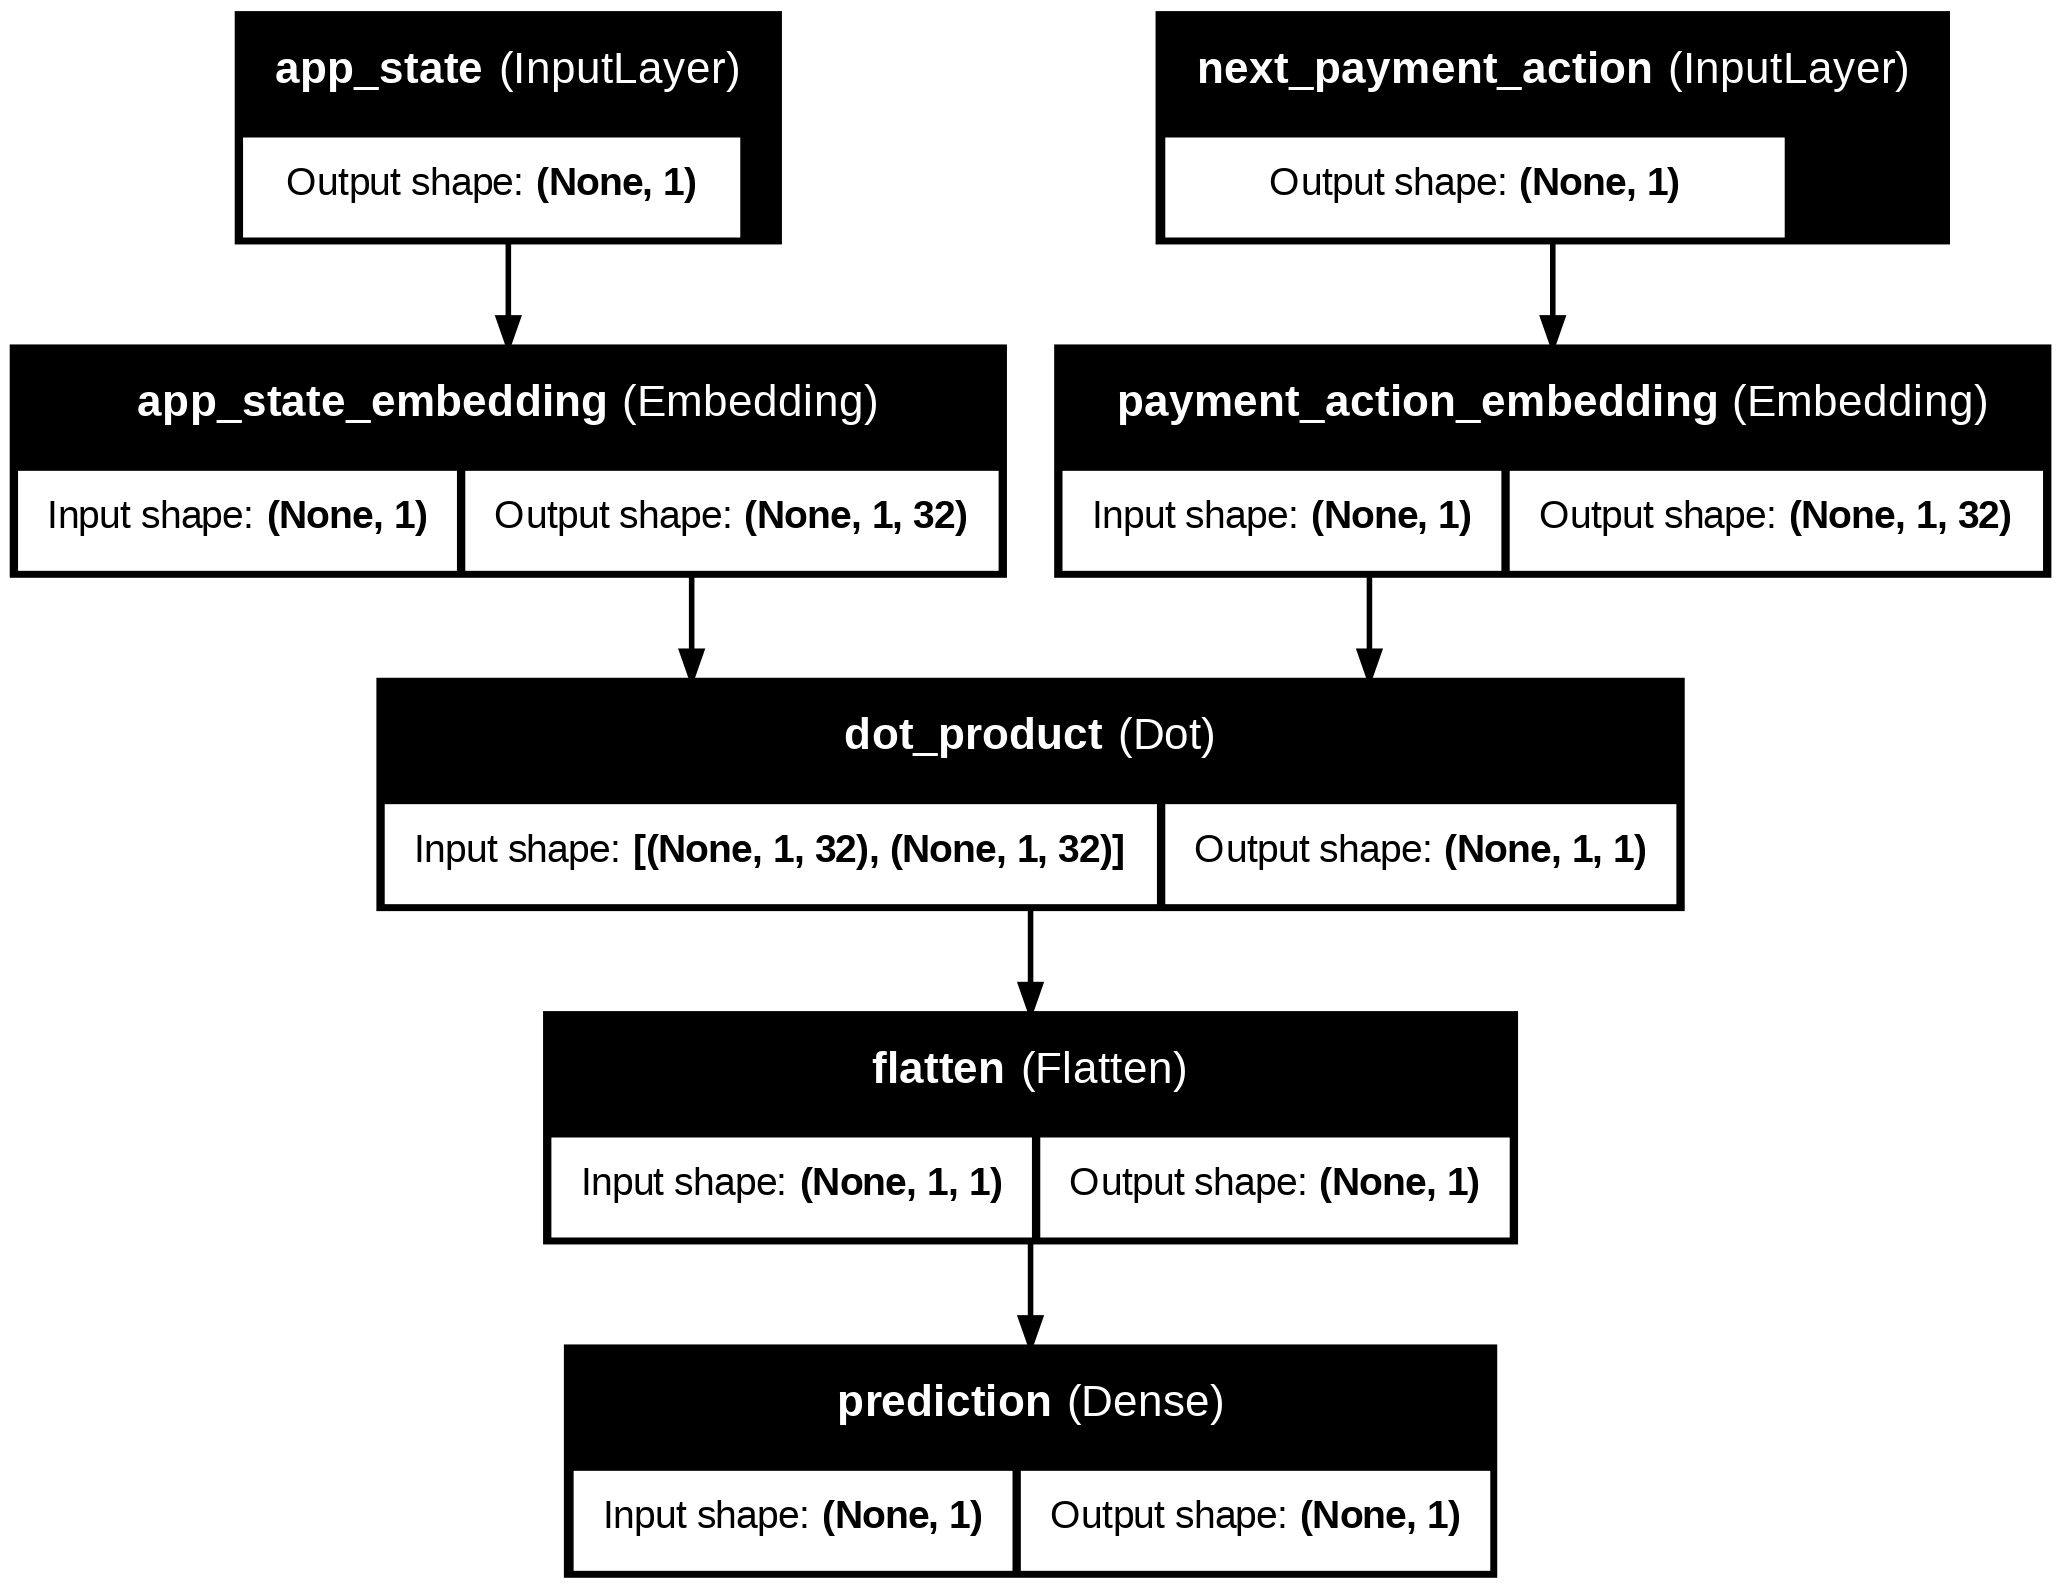

In [58]:
from tensorflow.keras.utils import plot_model
# 2. Generate and save the architectural plot
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)


In [60]:
model.inputs

[<KerasTensor shape=(None, 1), dtype=uint16, sparse=False, ragged=False, name=app_state>,
 <KerasTensor shape=(None, 1), dtype=uint16, sparse=False, ragged=False, name=next_payment_action>]

In [61]:
#convert model to TFLite
tf_model_name = "recommendation_0.2.1-alpha.tflite"
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(tf_model_name, "wb") as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpgpu9r1rl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 1), dtype=tf.uint16, name='app_state'), TensorSpec(shape=(None, 1), dtype=tf.uint16, name='next_payment_action')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133834841517392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834841517584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834841517200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133834841517968: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [62]:
!ls

Banking-Dataset		recommendation_0.2.1-alpha.tflite
model_architecture.png	sample_data


In [63]:
!ls -sh

total 17M
4.0K Banking-Dataset	      17M recommendation_0.2.1-alpha.tflite
128K model_architecture.png  4.0K sample_data


In [106]:
model.layers[2].get_weights()[0]

(65536, 32)

In [64]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [65]:
interpreter.get_input_details()

[{'name': 'serving_default_next_payment_action:0',
  'index': 0,
  'shape': array([1, 1], dtype=int32),
  'shape_signature': array([-1,  1], dtype=int32),
  'dtype': numpy.uint16,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0},
  'sparsity_parameters': {}},
 {'name': 'serving_default_app_state:0',
  'index': 1,
  'shape': array([1, 1], dtype=int32),
  'shape_signature': array([-1,  1], dtype=int32),
  'dtype': numpy.uint16,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0},
  'sparsity_parameters': {}}]

In [66]:
interpreter.get_output_details()

[{'name': 'StatefulPartitionedCall_1:0',
  'index': 27,
  'shape': array([1, 1], dtype=int32),
  'shape_signature': array([-1,  1], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0},
  'sparsity_parameters': {}}]

In [67]:
input_tensor_index = interpreter.get_input_details()[0]["index"]
output = interpreter.tensor(interpreter.get_output_details()[0]["index"])

In [68]:
#app_st = np.array("this_is_a_test5").reshape(1, 1).astype(str)
#pay_act = np.array("this_is_a_test5").reshape(1, 1).astype(str)

In [69]:
user_actions_map

{'Dashboard': 0,
 'Account_Details': 1,
 'Transaction_Historical': 2,
 'BENEF_INTERBANK_PAYMENT:RENT': 3,
 'BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO': 4,
 'SERVICE_PAYMENT:ELECTRICITY': 5,
 'SERVICE_PAYMENT:INTERNET': 6,
 'SERVICE_PAYMENT:PHONE': 7,
 'SERVICE_PAYMENT:NETFLIX': 8,
 'SERVICE_PAYMENT:WATER': 9,
 'PAYMENT_EXPRESS:PURCHASES': 10}

In [70]:
accounts_map

{'dqUy7gI2Q0axcw65lBEyUg==': 0}

In [86]:
np.random.choice(2**16, (1, 1)).astype(np.uint16)

array([[30167]], dtype=uint16)

In [93]:
#test model by running puntual predictions
for key, value in user_actions_map.items():
  #if value == 0:
  #  continue
  app_status = np.random.choice(2**16, (1, 1)).astype(np.uint16)#np.int16([-10]).reshape(1, 1).astype(np.uint16)#np.array([encode(dom=1, login_status=0, feature_key1=0, feature_key2=2)]).reshape(1, 1).astype(np.uint16)
  potential_next_action = np.array([value]).reshape(1, 1).astype(np.uint16)
  interpreter.set_tensor(input_tensor_index, app_status)
  interpreter.set_tensor(1, potential_next_action)
  interpreter.invoke()
  print(f"{key}: {output()}")

Dashboard: [[0.5261609]]
Account_Details: [[0.5260941]]
Transaction_Historical: [[0.5256902]]
BENEF_INTERBANK_PAYMENT:RENT: [[0.5270799]]
BENEF_INTERBANK_PAYMENT:FINANCIAMIENTO: [[0.5262728]]
SERVICE_PAYMENT:ELECTRICITY: [[0.5257783]]
SERVICE_PAYMENT:INTERNET: [[0.5262784]]
SERVICE_PAYMENT:PHONE: [[0.52687025]]
SERVICE_PAYMENT:NETFLIX: [[0.5257056]]
SERVICE_PAYMENT:WATER: [[0.52542174]]
PAYMENT_EXPRESS:PURCHASES: [[0.52669406]]


In [129]:
tensor_details = interpreter.get_tensor_details()

In [136]:
for tensor in tensor_details:
  if "embedding" in tensor["name"].lower() or "kernel" in tensor["name"].lower():
    print(tensor)
    weights_array = interpreter.get_tensor(tensor["index"])
    print(weights_array)
  #print(interpreter.get_tensor(tensor))

{'name': 'functional_1/app_state_embedding_1/Cast', 'index': 11, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
[[1057401643]]
{'name': 'functional_1/app_state_embedding_1/Less', 'index': 12, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.bool'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
[[ True]]
{'name': 'functional_1/app_state_embedding_1/add', 'index': 13, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales'

In [121]:
interpreter.get_tensor_details()

[{'name': 'serving_default_next_payment_action:0',
  'index': 0,
  'shape': array([1, 1], dtype=int32),
  'shape_signature': array([-1,  1], dtype=int32),
  'dtype': numpy.uint16,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0},
  'sparsity_parameters': {}},
 {'name': 'serving_default_app_state:0',
  'index': 1,
  'shape': array([1, 1], dtype=int32),
  'shape_signature': array([-1,  1], dtype=int32),
  'dtype': numpy.uint16,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_points': array([], dtype=int32),
   'quantized_dimension': 0},
  'sparsity_parameters': {}},
 {'name': 'arith.constant',
  'index': 2,
  'shape': array([1], dtype=int32),
  'shape_signature': array([1], dtype=int32),
  'dtype': numpy.float32,
  'quantization': (0.0, 0),
  'quantization_parameters': {'scales': array([], dtype=float32),
   'zero_point

In [107]:
model.layers[2].get_weights()[0]

array([[ 0.0206075 ,  0.0190011 , -0.00924738, ...,  0.02478839,
        -0.01347905,  0.04216416],
       [-0.04893339, -0.03264797,  0.01149993, ..., -0.04022019,
        -0.00710958, -0.04528735],
       [-0.0435428 ,  0.03783573,  0.02275658, ..., -0.00835316,
         0.03285314,  0.01448499],
       ...,
       [-0.00887505, -0.01492032, -0.04434728, ...,  0.00679231,
         0.03402159, -0.03687625],
       [ 0.01996205, -0.01305965, -0.03631366, ..., -0.02819482,
        -0.00673655,  0.01260142],
       [-0.00152989,  0.02814018, -0.04443002, ..., -0.02274829,
        -0.00342197, -0.01729289]], dtype=float32)

In [112]:
app_st = np.array([encode(dom=1, login_status=0, feature_key1=10, feature_key2=20)]).reshape(1, 1).astype(np.uint16)
pay_act = np.array([user_actions_map['SERVICE_PAYMENT:WATER']]).reshape(1, 1).astype(np.uint16)

In [113]:
pay_act

array([[9]], dtype=uint16)

In [114]:
interpreter.set_tensor(input_tensor_index, app_status)
interpreter.set_tensor(1, pay_act)


In [115]:
# Run inference.
result = interpreter.invoke()

In [116]:
output()

array([[0.5260493]], dtype=float32)

In [117]:
interpreter.get_tensor(output())

array([[12477]], dtype=uint16)

In [ ]:
# Pre-processing: add batch dimension and convert to float32 to match with
# the model's input data format.
test_image = np.expand_dims(test_image, axis=0).astype(np.float32)
interpreter.set_tensor(input_tensor_index, test_image)

# Run inference.
interpreter.invoke()

,prediction-label
8000,True
8001,True
8002,False
8003,True
8004,False
...,...
9668,False
9669,False
9670,True
9671,False


In [ ]:
# A helper function to evaluate the TF Lite model using "test" dataset.
def evaluate_tflite_model(tflite_model):
  # Initialize TFLite interpreter using the model.
  interpreter = tf.lite.Interpreter(model_content=tflite_model)
  interpreter.allocate_tensors()
  input_tensor_index = interpreter.get_input_details()[0]["index"]
  output = interpreter.tensor(interpreter.get_output_details()[0]["index"])

  # Run predictions on every image in the "test" dataset.
  prediction_digits = []
  for test_image in test_images:
    # Pre-processing: add batch dimension and convert to float32 to match with
    # the model's input data format.
    test_image = np.expand_dims(test_image, axis=0).astype(np.float32)
    interpreter.set_tensor(input_tensor_index, test_image)

    # Run inference.
    interpreter.invoke()

    # Post-processing: remove batch dimension and find the digit with highest
    # probability.
    digit = np.argmax(output()[0])
    prediction_digits.append(digit)

  # Compare prediction results with ground truth labels to calculate accuracy.
  accurate_count = 0
  for index in range(len(prediction_digits)):
    if prediction_digits[index] == test_labels[index]:
      accurate_count += 1
  accuracy = accurate_count * 1.0 / len(prediction_digits)

  return accuracy

# Evaluate the TF Lite float model. You'll find that its accurary is identical
# to the original TF (Keras) model because they are essentially the same model
# stored in different format.
float_accuracy = evaluate_tflite_model(tflite_float_model)
print('Float model accuracy = %.4f' % float_accuracy)

# Evalualte the TF Lite quantized model.
# Don't be surprised if you see quantized model accuracy is higher than
# the original float model. It happens sometimes :)
quantized_accuracy = evaluate_tflite_model(tflite_quantized_model)
print('Quantized model accuracy = %.4f' % quantized_accuracy)
print('Accuracy drop = %.4f' % (float_accuracy - quantized_accuracy))


In [ ]:
from google.colab import files
files.download(tf_model_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
word_to_ix = {"hello": 0, "world": 1}
embeding = nn.Embedding(4, 3)
lookup_tensor = torch.tensor([word_to_ix["hello"]], dtype=torch.long)
hello_embed = embeding(lookup_tensor)
print(hello_embed)

tensor([[1.0375, 0.8760, 1.0314]], grad_fn=<EmbeddingBackward0>)


In [ ]:
embeding(torch.tensor([3]))

tensor([[0.7467, 0.0948, 0.4407]], grad_fn=<EmbeddingBackward0>)

In [ ]:
'''
Define a vocab space with the following considerations:
1. The vocabulary will be an encoded int representation of all finite and possible
    App states
2. Overhead should be allocated in the space for possible expansion
3. The App should track all feature combinations and account for encoding new states/features
4. The DOM temporal feature should be the first input feature for the encoder
5. Use a zero (0) to represent the colon (:) separator in the int sequence
6. Use an int b 1<=b<=3 to encode the balance status for a given account, as
denoted in the dictionary:
d = {
  "NEGATIVE": 1,
  "FLAT": 2,
  "POSITIVE": 3
}


In [ ]:
CONTEXT_SIZE = 2
EMBEDDING_DIM = 10
# We will use Shakespeare Sonnet 2
test_sentence = """When forty winters shall besiege thy brow,
And dig deep trenches in thy beauty's field,
Thy youth's proud livery so gazed on now,
Will be a totter'd weed of small worth held:
Then being asked, where all thy beauty lies,
Where all the treasure of thy lusty days;
To say, within thine own deep sunken eyes,
Were an all-eating shame, and thriftless praise.
How much more praise deserv'd thy beauty's use,
If thou couldst answer 'This fair child of mine
Shall sum my count, and make my old excuse,'
Proving his beauty by succession thine!
This were to be new made when thou art old,
And see thy blood warm when thou feel'st it cold.""".split()
# we should tokenize the input, but we will ignore that for now
# build a list of tuples.
# Each tuple is ([ word_i-CONTEXT_SIZE, ..., word_i-1 ], target word)
ngrams = [
    (
        [test_sentence[i - j - 1] for j in range(CONTEXT_SIZE)],
        test_sentence[i]
    )
    for i in range(CONTEXT_SIZE, len(test_sentence))
]

In [ ]:
ngrams

[(['forty', 'When'], 'winters'),
 (['winters', 'forty'], 'shall'),
 (['shall', 'winters'], 'besiege'),
 (['besiege', 'shall'], 'thy'),
 (['thy', 'besiege'], 'brow,'),
 (['brow,', 'thy'], 'And'),
 (['And', 'brow,'], 'dig'),
 (['dig', 'And'], 'deep'),
 (['deep', 'dig'], 'trenches'),
 (['trenches', 'deep'], 'in'),
 (['in', 'trenches'], 'thy'),
 (['thy', 'in'], "beauty's"),
 (["beauty's", 'thy'], 'field,'),
 (['field,', "beauty's"], 'Thy'),
 (['Thy', 'field,'], "youth's"),
 (["youth's", 'Thy'], 'proud'),
 (['proud', "youth's"], 'livery'),
 (['livery', 'proud'], 'so'),
 (['so', 'livery'], 'gazed'),
 (['gazed', 'so'], 'on'),
 (['on', 'gazed'], 'now,'),
 (['now,', 'on'], 'Will'),
 (['Will', 'now,'], 'be'),
 (['be', 'Will'], 'a'),
 (['a', 'be'], "totter'd"),
 (["totter'd", 'a'], 'weed'),
 (['weed', "totter'd"], 'of'),
 (['of', 'weed'], 'small'),
 (['small', 'of'], 'worth'),
 (['worth', 'small'], 'held:'),
 (['held:', 'worth'], 'Then'),
 (['Then', 'held:'], 'being'),
 (['being', 'Then'], 'asked